In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import sys 
import glob
import torch 
import os
from tqdm import tqdm
from torch.utils.data import DataLoader
import gc

### defining functions

In [2]:
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/transforms")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/configs")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/plots")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/models")

In [3]:
from fixed_dataset import FixedDataset
from seg_recon_vit3d import SegRecon_ViT_3D
from transforms.factory import transform_factory
from utils.read_yaml import read_yaml
from utils.model_select import model_select
from utils.load_ckpt import load_best_ckpt
from loss import loss_select
from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore
from transforms import *
from transforms import FourierSpectralTransform
from transforms.inverse_factory import *

/home/ana-caznok/software/src/miniforge3/envs/agrvai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def plot_channel_differences(y: torch.Tensor, out: torch.Tensor, channels: list,model_name:str, base_path = "/media/ana-caznok/SSD-08/recon-segment/"):
    """
    Plots the difference between corresponding channels of `y` and `out` for the specified channels.

    Parameters:
    - y (torch.Tensor): Tensor of shape (61, 256, 256)
    - out (torch.Tensor): Tensor of shape (1, 61, 256, 256)
    - channels (list of int): List of channel indices to plot
    """
    # Remove the batch dimension from `out`, now shape (61, 256, 256)
    out = out.squeeze(0)

    # Verify tensor shapes
    assert y.shape == out.shape == (61, 256, 256), "Shape mismatch: Expected (61, 256, 256)"

    # Compute the difference for each selected channel and store in a list
    differences = [np.abs((y[c] - out[c]).detach().cpu().numpy()) for c in channels]

    # Determine global min and max for consistent color scale
    global_min = 0 #min(diff.min() for diff in differences)
    global_max = 1 #max(diff.max() for diff in differences)

    # Determine subplot layout
    n_channels = len(channels)
    ncols = min(4, n_channels)
    nrows = (n_channels + ncols - 1) // ncols

    # Create figure and axes
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if n_channels > 1 else [axes]

    # Plot each channel difference
    for idx, (channel, diff) in enumerate(zip(channels, differences)):
        ax = axes[idx]
        im = ax.imshow(diff, cmap='magma', vmin=global_min, vmax=global_max)
        ax.set_title(f'Channel {channel} Difference')
        ax.axis('off')

    # Turn off unused subplots if any
    for idx in range(len(differences), len(axes)):
        axes[idx].axis('off')

    # Add a common colorbar
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    fig.suptitle(model_name)

    # Adjust layout to prevent overlap
    #plt.tight_layout()
    plt.savefig(base_path + 'plots/' + 'err_' + model_name + '.png')

    plt.show()

In [5]:
def plot_output_channels(
    out: torch.Tensor,
    channels: list,
    model_name: str,
    base_path: str = "/media/ana-caznok/SSD-08/recon-segment/"):
    
    # Remove batch dimension, resulting shape (C, H, W)
    out = out.squeeze(0)

    # Check if output has correct dimensions
    assert out.ndim == 3, "Expected tensor shape (C, H, W) after squeezing batch dimension"

    # Extract the selected channels and move to CPU
    selected_images = [out[c].detach().cpu().numpy() for c in channels]

    # Determine layout for subplots
    n_channels = len(channels)
    ncols = min(4, n_channels)
    nrows = (n_channels + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if n_channels > 1 else [axes]

    # Plot each selected channel
    for idx, (channel, img) in enumerate(zip(channels, selected_images)):
        ax = axes[idx]
        im = ax.imshow(img, cmap='gray')
        ax.set_title(f'Channel {channel}')
        ax.axis('off')

    # Turn off unused axes if there are any
    for idx in range(len(selected_images), len(axes)):
        axes[idx].axis('off')

    # Add colorbar for last image
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    fig.suptitle(f'Output Channels - {model_name}')

    # Save the figure
    plt.savefig(base_path + 'plots/' + 'out_channels_' + model_name + '.png')
    plt.show()


In [6]:
def plot_spectral_input(x, output, y, 
                        tp, 
                        model_name, 
                        points=[(148, 140), (40, 40)], 
                        base_path: str = "/media/ana-caznok/SSD-08/recon-segment/"):
    # Squeeze output if it has a batch dimension
    if output.ndim == 4:
        output = output.squeeze(0)

    # Move tensors to numpy
    y = y.detach().cpu().numpy()
    output = output.detach().cpu().numpy()
    x = x.detach().cpu().numpy()

    if tp =='msi':
        wavl = np.linspace(400,1000,61)
        rgbnir = [420,500,630,960] 
        _,wavl_idx = np.unique(wavl,return_index=True)
        rgbnir_idx = wavl_idx[np.isin(wavl, rgbnir)]
        x_plot = rgbnir_idx
        x_min,x_max = wavl_idx[0], wavl_idx[-1]
        x_domain = 'wavelenght'

    else:
        x_plot = np.arange(0,x.shape[0],1)
        x_min,x_max = 0, x.shape[0]

    # Create 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    input_colors = ['hotpink', 'red']
    my_colors = ['turquoise', 'teal', 'mediumorchid', 'darkorchid']

    # --- TOP LEFT: Middle band of input x ---
    mid_band = x.shape[0] // 2
    axs[0, 0].imshow(x[mid_band, :, :], cmap='gray')
    axs[0, 0].set_title(f"Input Image - Band {mid_band}")

    # Mark selected points
    for i, (row, col) in enumerate(points):
        axs[0, 0].plot(col, row, '*', color=input_colors[i], markersize=10)

    # --- TOP RIGHT: Spectral values from input x ---
    for i, (row, col) in enumerate(points):
        axs[0, 1].plot(x_plot, x[:, row, col],'o', color=input_colors[i], label=f'Input ({row},{col})')
        

    axs[0, 1].set_title("Spectral Signature of Input (x)")
    axs[0, 1].set_xlabel("Band Index")
    axs[0, 1].set_ylabel("Intensity")
    axs[0,1].set_xlim([x_min,x_max])
    axs[0, 1].legend()

    # --- BOTTOM LEFT: GT image with points ---
    axs[1, 0].imshow(y[30, :, :], cmap='gray')
    axs[1, 0].set_title("GT Band 30 with Points")
    for i, (row, col) in enumerate(points):
        axs[1, 0].plot(col, row, '*', color=my_colors[i*2 + 1], markersize=10)

    # --- BOTTOM RIGHT: GT vs Output Spectra ---
    for i, (row, col) in enumerate(points):
        axs[1, 1].plot(y[:, row, col], color=my_colors[i*2], label=f'GT ({row},{col})')
        axs[1, 1].plot(output[:, row, col], color=my_colors[i*2 + 1], linestyle='-.', label=f'Output ({row},{col})')
    axs[1, 1].set_title("Spectral Comparison (GT vs Output)")
    axs[1, 1].set_xlabel("Band Index")
    axs[1, 1].set_ylabel("Intensity")
    axs[1, 1].legend()

    # Overall figure title and layout adjustment
    fig.suptitle(model_name, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(base_path + 'in-out_' + model_name + 'png')
    plt.show()


In [7]:
def plot_spectral_diff(y, output, model_name, points=[(148, 140), (40, 40)]):
    """
    Plots spectral differences between ground truth and model output at given spatial points.

    Parameters:
        y (Tensor or ndarray): Ground truth hyperspectral data of shape (bands, H, W).
        output (Tensor or ndarray): Model output data, expected to be (1, bands, H, W) or (bands, H, W).
        model_name (str): Title for the plot.
        points (list of tuple): List of (row, col) coordinates for which to plot spectra.
    """
    
    # Remove batch dimension if present
    if output.ndim == 4:
        output = output.squeeze(0)
    y = y.detach().cpu().numpy()
    output = output.detach().cpu().numpy()
    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    
    # Show a grayscale image at an arbitrary band (e.g., 30)
    axs[0].imshow(y[30, :, :], cmap='gray')
    axs[0].set_title("Spatial Locations")
    
    my_colors = ['teal', 'darkorange']
    
    for i, (row, col) in enumerate(points):
        # Mark point on the image
        axs[0].plot(col, row, '*', color=my_colors[i], markersize=10)
        
        # Plot ground truth and output spectra at this point
        axs[1].plot(y[:, row, col], color=my_colors[i], label=f'GT ({row},{col})')
        axs[1].plot(output[:, row, col], color=my_colors[i], linestyle='-.', label=f'Output ({row},{col})')
    
    axs[1].set_title("Spectral Comparison")
    axs[1].set_xlabel("Spectral Band")
    axs[1].set_ylabel("Intensity")
    axs[1].legend()
    
    fig.suptitle(model_name)
    plt.tight_layout()
    plt.show()

### main

In [8]:
base_path = "/media/ana-caznok/SSD-08/recon-segment/"
config_path = "/media/ana-caznok/SSD-08/recon-segment/configs/"

In [9]:
configs = [#'stable_fft2ifft2hsi_1000_none_cluster_xmin.yaml',
           #'fft2hsi_1000_mraessimsam_patch16.yaml', 
           #'msi2hsi_1000_mraessimsam_patch16.yaml', 
           #'msi2mask_wsam_1000.yaml', 
           #'test_feedfoward2.yaml',
           #'test_overlap2.yaml',
           #'test_overlap_mraessimsam.yaml', 
           'restormer_msi2hsi_mraessimsam.yaml', 
           'restormer_fft2hsi_mraessimsam.yaml',
           'restormer_fft2ifft2hsi_mraessimsam.yaml', 
           'hscnn_msi2hsi_mraessimsam.yaml', 
           'hscnn_fft2hsi_mraessimsam.yaml',
           'hscnn_fft2ifft2hsi_mraessimsam.yaml']

In [10]:
DEVICE = 'cuda'
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled"
PREPROCESSING = 'downsampled' 
BATCH_SIZE = 1

restormer_4to61
Looking for checkpoint in models/restormer_msi2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/restormer_msi2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49
Resuming from epoch 50/50
Resuming W&B run ID: 8gnalkti


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Selected model restormer_4to61: Restormer
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None


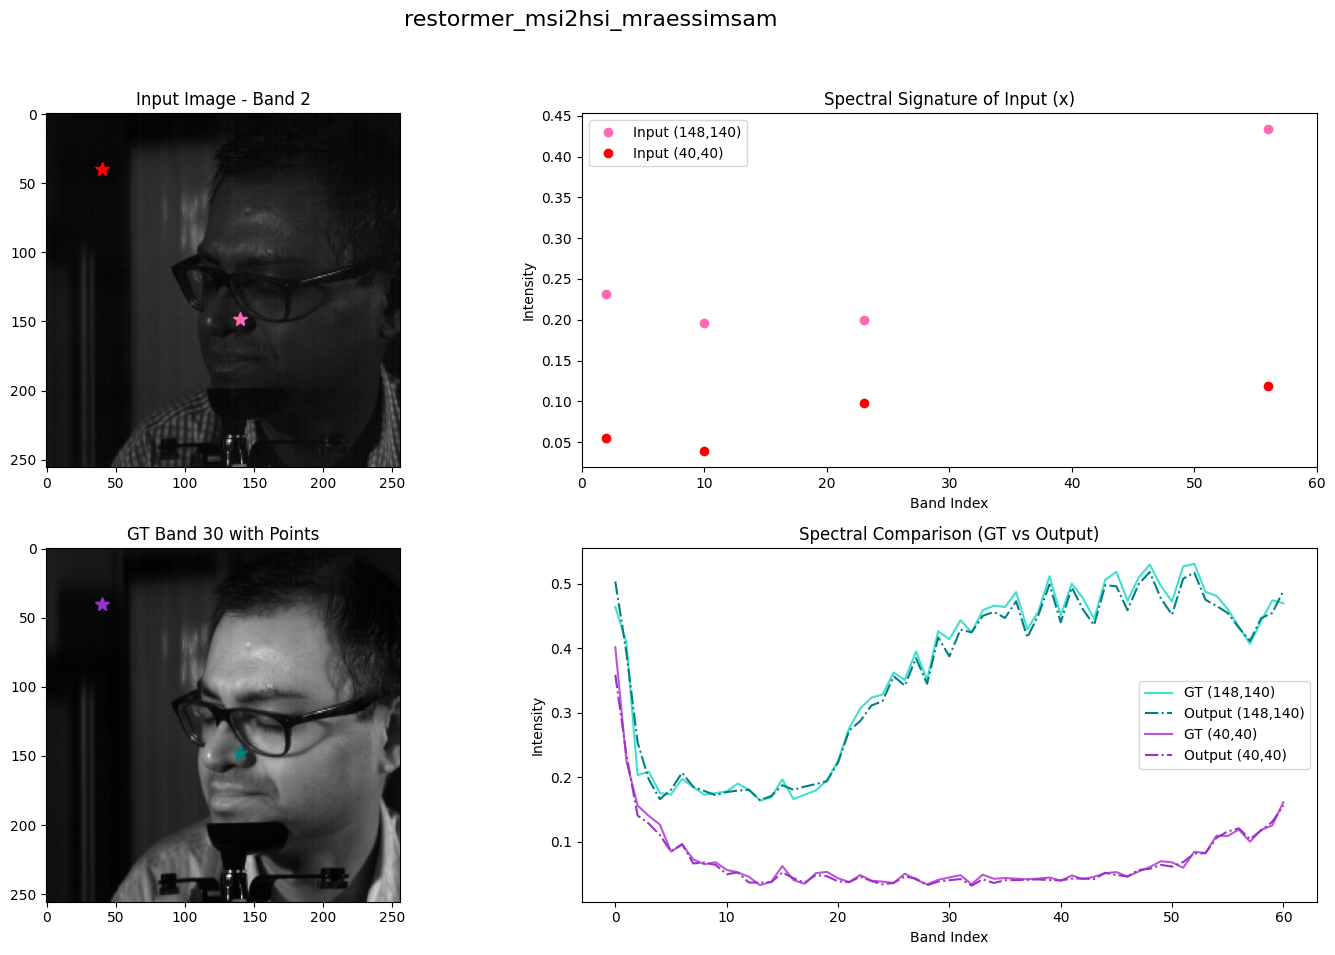

restormer_31to61
Looking for checkpoint in models/restormer_fft2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/restormer_fft2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Resuming from epoch 50/50
Resuming W&B run ID: gzmgpvct
Selected model restormer_31to61: Restormer
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform 
0: RGB2Pseudo_Hyp(base_path='/media/ana-caznok/SSD-08/recon-segment/', camera='D40', norm=False, return_torch=True)
1: FourierSpectralTransform(norm=minmax,double RealImag=False ,transform cube=False, device=cuda, shift=True,stack_type=alternate, invert=False ). Fold: None


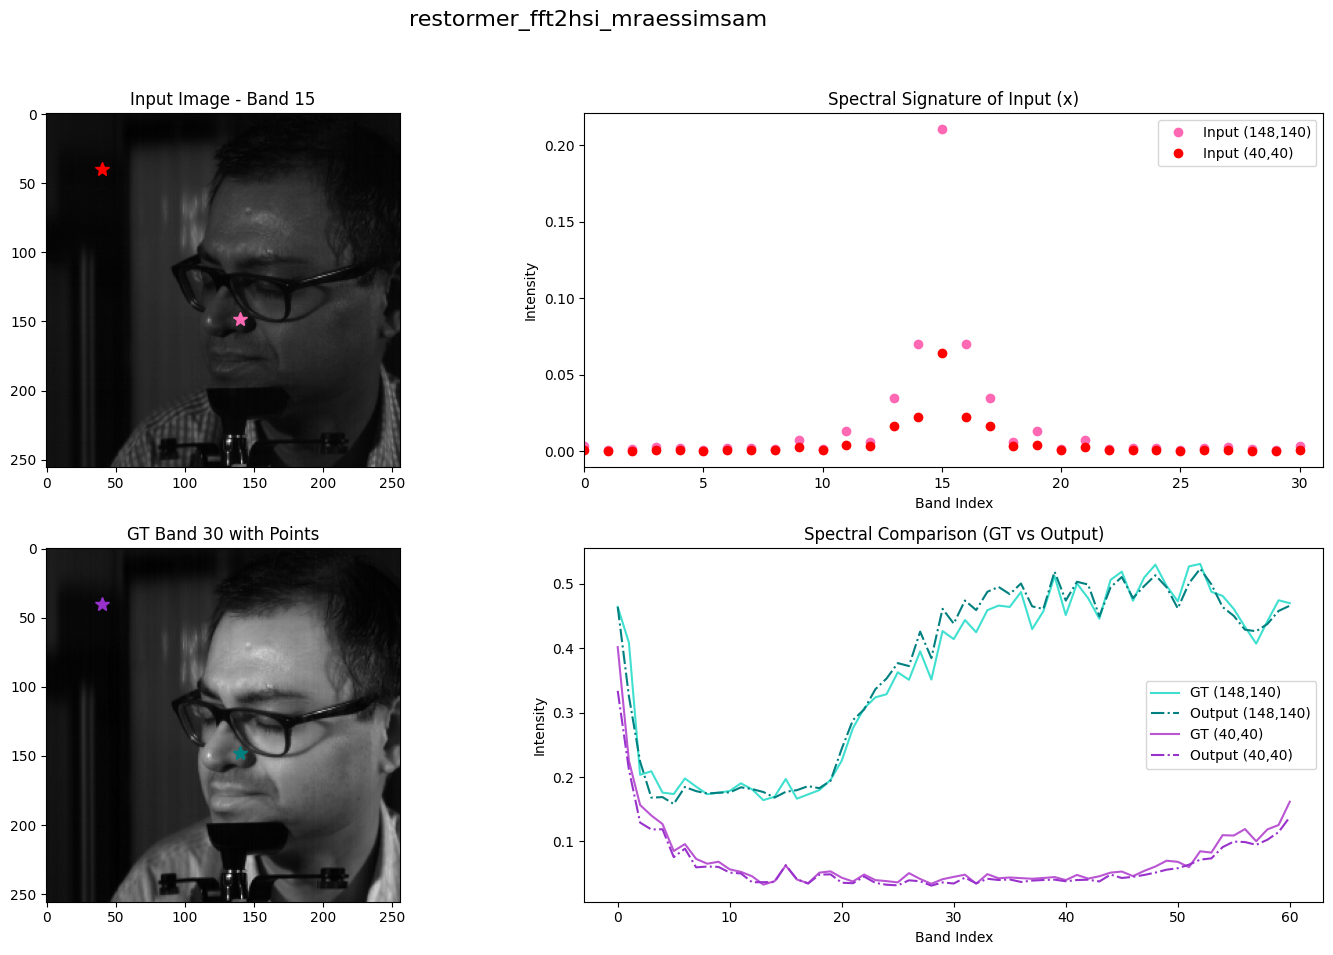

restormer_62to122
Looking for checkpoint in models/restormer_fft2ifft2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/restormer_fft2ifft2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49
Resuming from epoch 50/50
Resuming W&B run ID: xtj062kj
Selected model restormer_62to122: Restormer


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform 
0: RGB2Pseudo_Hyp(base_path='/media/ana-caznok/SSD-08/recon-segment/', camera='cie', norm=True, return_torch=True)
1: FourierSpectralTransform(norm=None,double RealImag=True ,transform cube=False, device=cuda, shift=True,stack_type=alternate, invert=False ). Fold: None


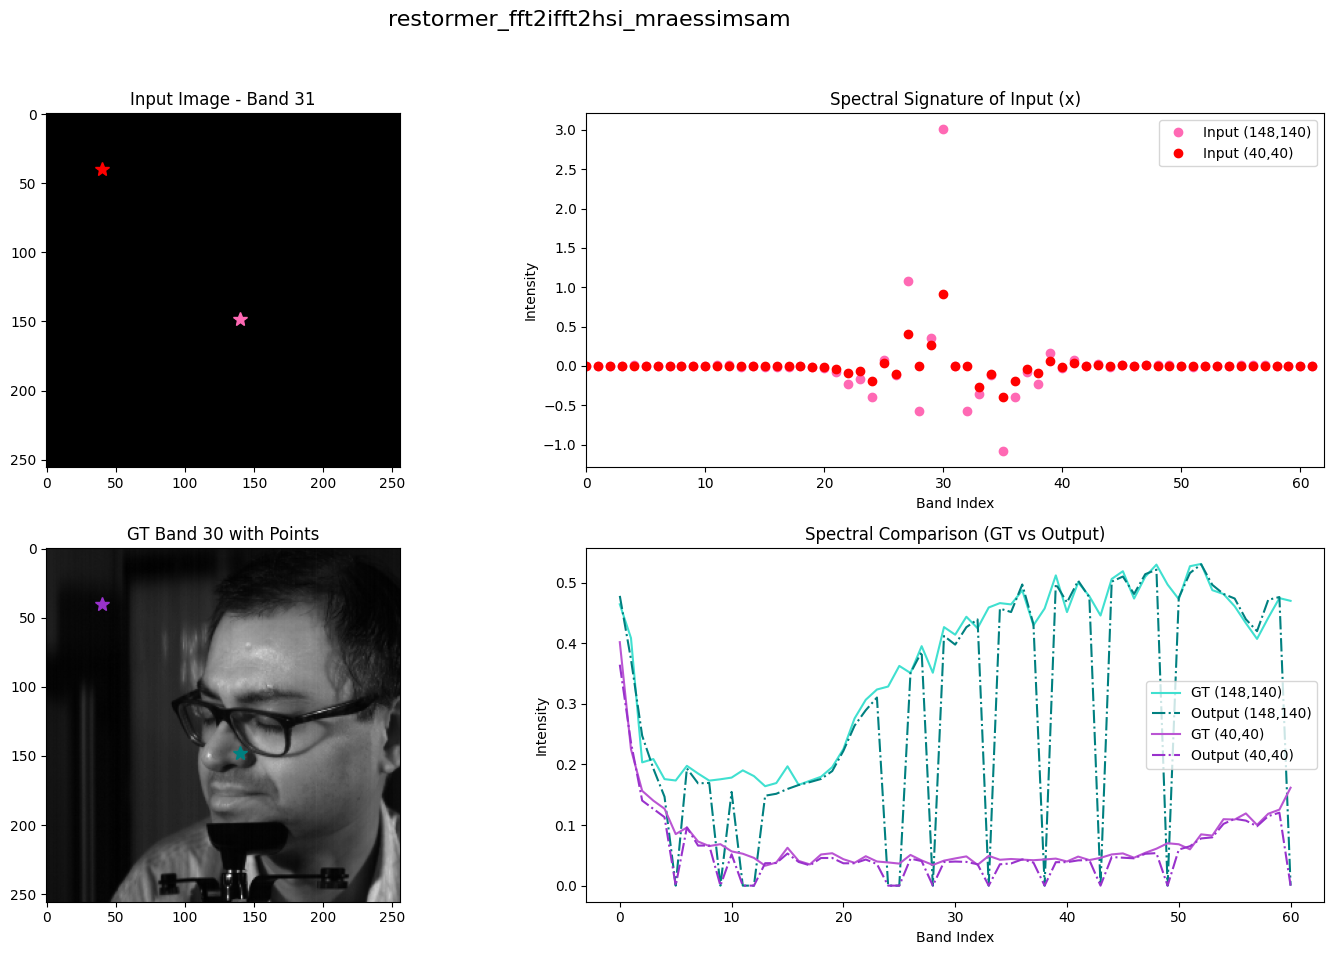

hscnn_4to61
Looking for checkpoint in models/hscnn_msi2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/hscnn_msi2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49
Resuming from epoch 50/50
Resuming W&B run ID: t88zly3d
Selected model hscnn_4to61: HSCNN_Plus
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

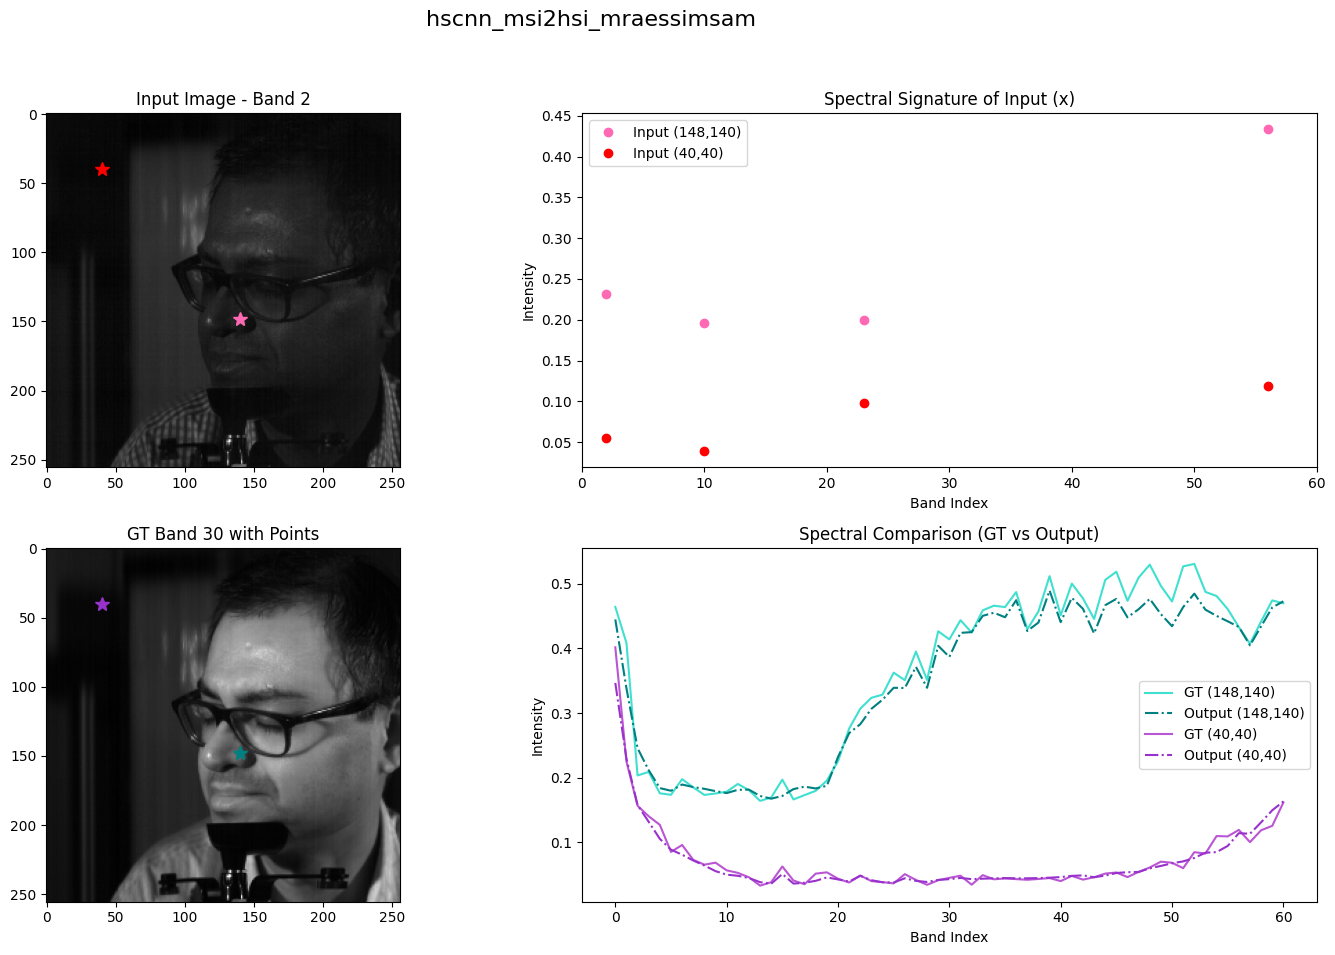

hscnn_31to61
Looking for checkpoint in models/hscnn_fft2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/hscnn_fft2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49
Resuming from epoch 50/50
Resuming W&B run ID: 7c1j0zb4
Selected model hscnn_31to61: HSCNN_Plus
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform 
0: RGB2Pseudo_Hyp(base_path='/media/ana-caznok/SSD-08/recon-segment/', camera='D40', norm=False, return_torch=True)
1: FourierSpectralTransform(norm=minmax,double RealImag=False ,transform cube=False, device=cuda, shift=True,stack_type=alternate, invert=False ). Fold: None


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

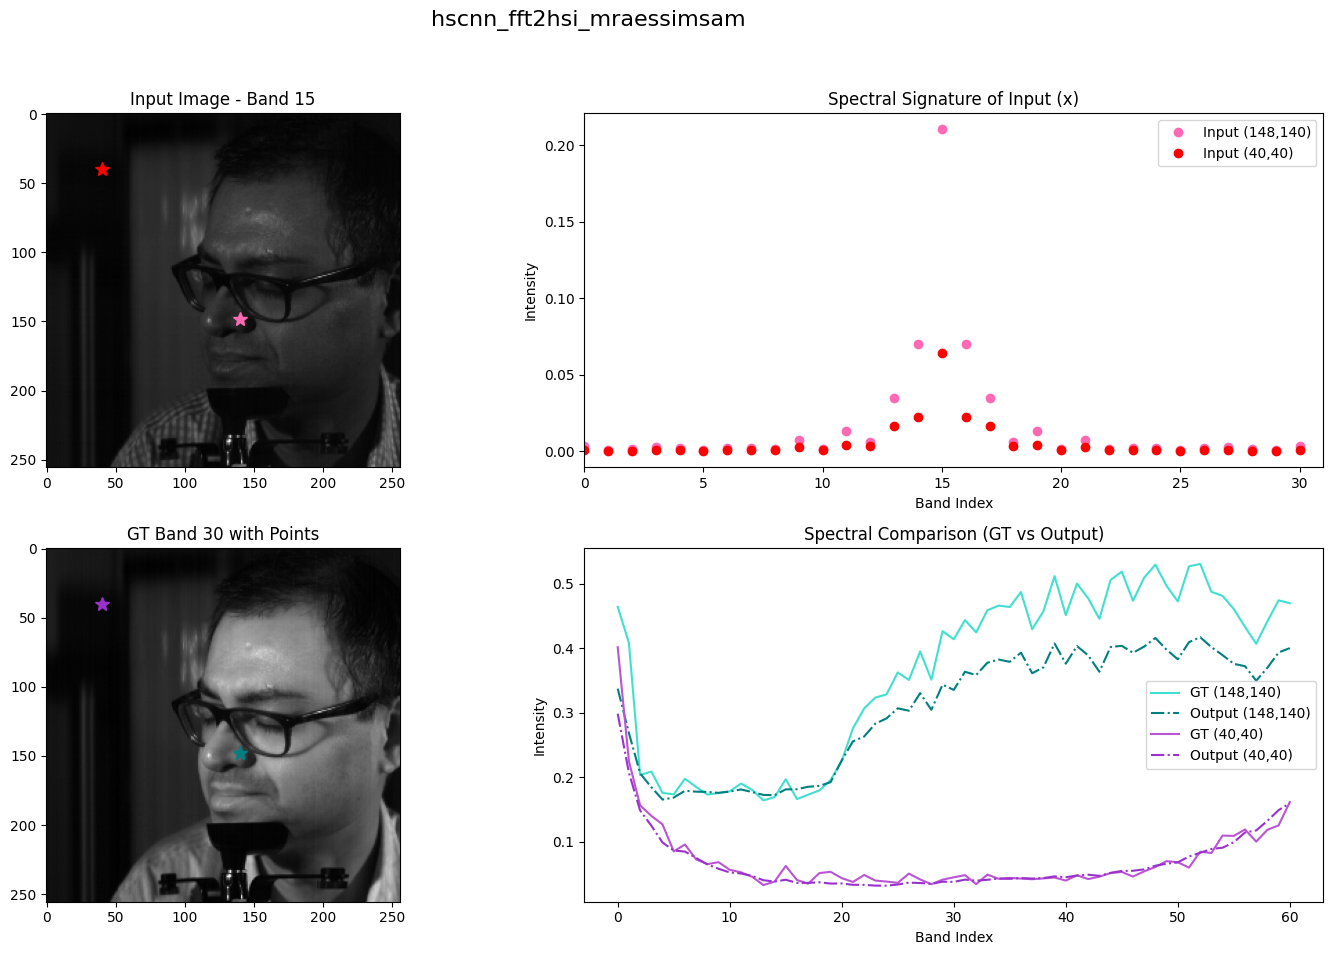

hscnn_62to122
Looking for checkpoint in models/hscnn_fft2ifft2hsi_mraessimsam.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/hscnn_fft2ifft2hsi_mraessimsam.pth'
Loaded checkpoint from epoch: 49
Resuming from epoch 50/50
Resuming W&B run ID: k7cf5g82
Selected model hscnn_62to122: HSCNN_Plus
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform 
0: RGB2Pseudo_Hyp(base_path='/media/ana-caznok/SSD-08/recon-segment/', camera='cie', norm=True, return_torch=True)
1: FourierSpectralTransform(norm=None,double RealImag=True ,transform cube=False, device=cuda, shift=True,stack_type=alternate, invert=False ). Fold: None


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

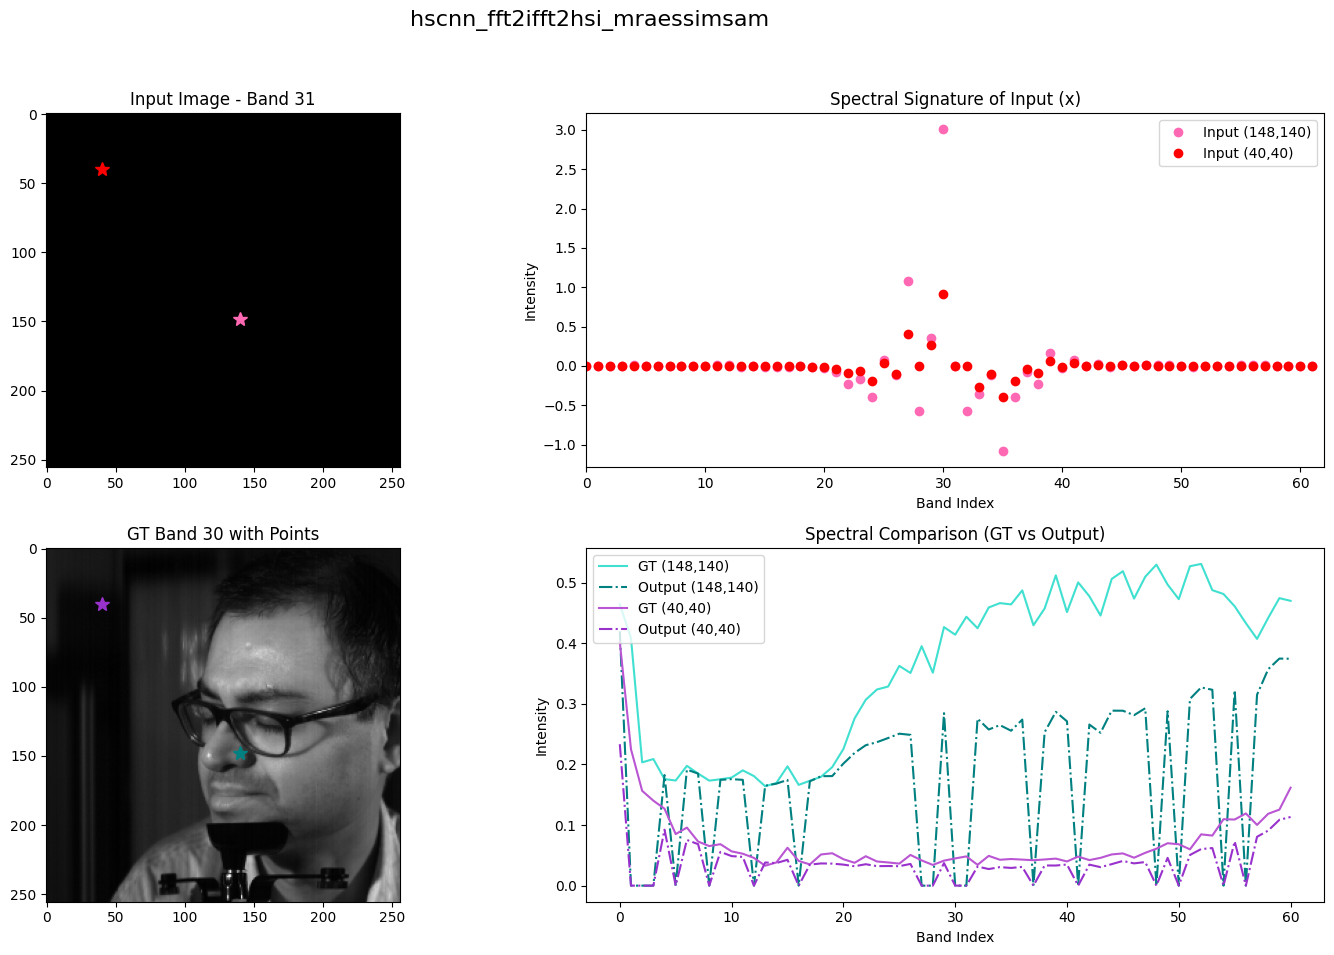

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [11]:
for config_name in configs: 
    model = []
    config = read_yaml(config_path + config_name)

    TRANSFORM = config['valid']['transform_index']
    MODEL_NAME = config['model']
    need_ifft = bool(config['ifft'])
    print(MODEL_NAME)

    model, resume_file = model_select(config)
    model = model.to(DEVICE)
   

    val_dataset = FixedDataset(mode="val",
                               base_path=BASE_PATH,
                               transform=transform_factory(TRANSFORM),
                               preprocessing=PREPROCESSING)
    
    x,y,m = val_dataset[1]
    x = x.to(DEVICE)
    del val_dataset

    if 'mask' in config_name: 
        output,mask = model(x.unsqueeze(0))
    
    else: 
        output = model(x.unsqueeze(0))

        if need_ifft: 
            ifft_output_function = inverse_transform_factory(TRANSFORM,output=True)
            output = ifft_output_function(output,m)
  
    x = x.detach().cpu()
    y = y.to(DEVICE)       

    name = config_name.split('.')[0]
    tp = name.split('_')[1].split('2h')[0]

    #plot_channel_differences(y, output, channels=[1, 5, 15, 25, 35, 45, 55, 60], model_name=name)
    #plot_output_channels(output,channels=[1, 5, 15, 25, 35, 45, 55, 60],model_name= name)
    #plot_spectral_diff(y,output,model_name=name)
    plot_spectral_input(x,output,y,model_name=name,tp=tp)

    del model, y, m, output, x
    torch.cuda.empty_cache()
    gc.collect()



In [ ]:
torch.cuda.empty_cache()
gc.collect()

In [ ]:
model, resume_file = model_select(config)

In [ ]:
mask = mask.detach().cpu().numpy()

In [ ]:
m['mask'] = m['mask'].cpu().numpy()

In [ ]:
plt.imshow(m['mask'][0,:,:],cmap='gray')
plt.imshow(mask[0,0, :,:],cmap='nipy_spectral', alpha=0.5, interpolation='none')
plt.show()

In [ ]:
mask.shape

In [ ]:
m['mask'].shape

In [ ]:
plot_channel_differences(y, output, channels=[1, 5, 15, 25, 35, 45, 55, 60])

In [ ]:
plot_mask = mask.detach().cpu().numpy()
plot_mask = mask[0,0,:,:].detach().numpy()
plt.imshow(plot_mask,cmap='gray')
plt.show()
#plot_mask.shape

In [ ]:
plot_mask = m['mask'].detach().cpu().numpy()
plot_mask = m['mask'][0,:,:].detach().numpy()
plt.imshow(plot_mask,cmap='gray')
plt.show()

In [ ]:
np.unique(plot_mask.detach().numpy())

In [ ]:
pth_path= base_path + 'models/' + config_name.split('.')[0] + '.pth'

In [ ]:
model, resume_file, best_loss = load_best_ckpt(model, config, exact_only=True)
checkpoint = torch.load(resume_file, map_location='cpu')

In [ ]:
checkpoint = torch.load(pth_path, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['state_dict'], strict=False)

#best_loss = checkpoint['best_loss']

In [ ]:
model, resume_file, best_loss = load_best_ckpt()